In [ ]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

plt.close('all') # close all open plots

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

In [3]:
# Filter df for jobs in United Kingdom
df_UK = df[(df["job_country"] == "United Kingdom")].copy()

In [4]:
# Add new column called job_posted_month
df_UK["job_posted_month_no"] = df_UK["job_posted_date"].dt.month

df_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,"[python, sql, power bi]","{'analyst_tools': ['power bi'], 'programming':...",10
45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,"[sql, python]","{'programming': ['sql', 'python']}",5
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,"[sql, r, python, tableau, power bi]","{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
97,Data Analyst,"Systems & Data Analyst - Exploitation, Missing...",United Kingdom,via Totaljobs,Full-time and Contractor,False,United Kingdom,2023-12-04 13:14:01,True,False,United Kingdom,NaN,NaN,NaN,Solihull Metropolitan Borough Council,None,NaN,12
152,Data Scientist,Data Science Team Lead,Anywhere,via OnlyDataJobs,Full-time,True,United Kingdom,2023-12-23 13:12:16,False,False,United Kingdom,NaN,NaN,NaN,StepStone Group,"[react, docker]","{'libraries': ['react'], 'other': ['docker']}",12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,NaN,NaN,Viatris,"[sql, sql server, excel, powerpoint]","{'analyst_tools': ['excel', 'powerpoint'], 'da...",10
785513,Data Scientist,Data Scientist,"Glasgow, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-22 06:21:21,False,False,United Kingdom,NaN,NaN,NaN,ASA Recruitment,"[r, power bi]","{'analyst_tools': ['power bi'], 'programming':...",1
785522,Data Engineer,Lead Data Engineer,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-19 06:16:45,True,False,United Kingdom,NaN,NaN,NaN,bionic-services-ltd,"[sql, python, sql server, aws, snowflake, ssis]","{'analyst_tools': ['ssis'], 'cloud': ['aws', '...",1
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,"[python, vue, ssis, ssrs, qlik, confluence, jira]","{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1


In [5]:
df_UK_exploded = df_UK.explode("job_skills")

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,python,"{'analyst_tools': ['power bi'], 'programming':...",10
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,sql,"{'analyst_tools': ['power bi'], 'programming':...",10
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,power bi,"{'analyst_tools': ['power bi'], 'programming':...",10
45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,sql,"{'programming': ['sql', 'python']}",5
45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,python,"{'programming': ['sql', 'python']}",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,qlik,"{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,confluence,"{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,jira,"{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1
785676,Senior Data Scientist,Senior Data Scientist,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-22 06:21:23,False,False,United Kingdom,NaN,NaN,NaN,Department for International Development,r,"{'programming': ['r', 'python']}",1


In [29]:
df_UK_exploded_pivot = df_UK_exploded.pivot_table(
    index="job_posted_month_no",
    columns="job_skills",
    aggfunc="size",
    fill_value=0 # fill empty cells with 0 instead of NaN
)

In [30]:
# Add a Total row at the bottom of the pivot table
df_UK_exploded_pivot.loc["Total"] = df_UK_exploded_pivot.sum()

In [31]:
# Sort pivot table based on Total row in descending order
df_UK_exploded_pivot = df_UK_exploded_pivot[df_UK_exploded_pivot.loc["Total"].sort_values(ascending=False).index]

df_UK_exploded_pivot = df_UK_exploded_pivot.drop("Total")

In [ ]:
# Convert index numbers (1, 2, 3...) to month names (Jan, Feb, Mar...) directly
df_UK_exploded_pivot.index = pd.to_datetime(df_UK_exploded_pivot.index, format='%m').strftime('%b')

In [34]:
df_UK_exploded_pivot

job_skills,sql,python,azure,aws,excel,power bi,r,tableau,spark,gcp,...,asp.net core,nuix,webex,huggingface,heroku,erlang,ionic,pascal,workfront,wrike
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
Jan,2450,2277,972,840,812,709,675,515,497,414,...,1,0,0,0,0,0,0,0,0,0
Feb,1853,1700,808,712,636,555,478,405,380,326,...,0,0,0,0,1,0,0,0,1,0
Mar,1393,1413,623,569,458,434,406,330,307,243,...,0,0,0,0,0,0,0,0,0,0
Apr,995,1031,435,425,309,293,287,218,233,191,...,0,0,0,0,0,0,1,0,0,0
May,1141,1127,473,471,342,336,318,241,220,208,...,0,0,0,0,0,0,0,0,0,0
Jun,1417,1455,612,595,418,418,354,286,335,239,...,0,0,0,0,0,0,0,1,0,0
Jul,1740,1663,823,708,559,595,418,329,366,305,...,0,0,0,0,0,0,0,0,0,0
Aug,1419,1470,621,560,401,402,382,268,297,254,...,0,0,0,0,0,0,0,0,0,0
Sep,2040,1937,845,791,715,658,548,480,392,292,...,0,2,0,1,0,1,0,0,0,1


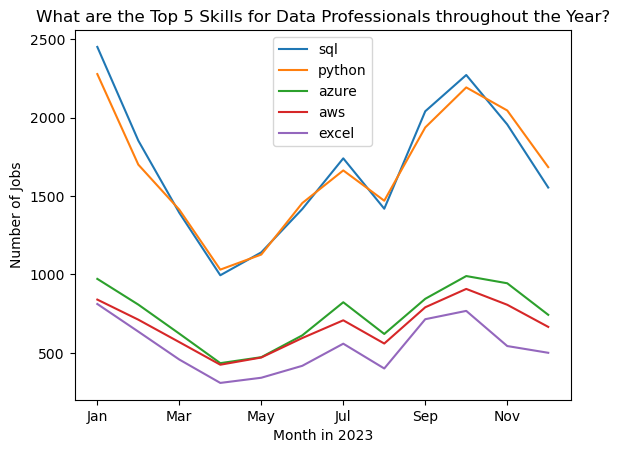

In [ ]:
# Plot top 5 skills on line grpah using Matplotlib
# Top 5 skills (columns) are accessed with .iloc method
df_UK_exploded_pivot.iloc[:, :5].plot(
    kind="line"
)
plt.title("What are the Top 5 Skills for Data Professionals throughout the Year?")
plt.legend() # Gives a proper legend
plt.xlabel("Month in 2023")
plt.ylabel("Number of Jobs");

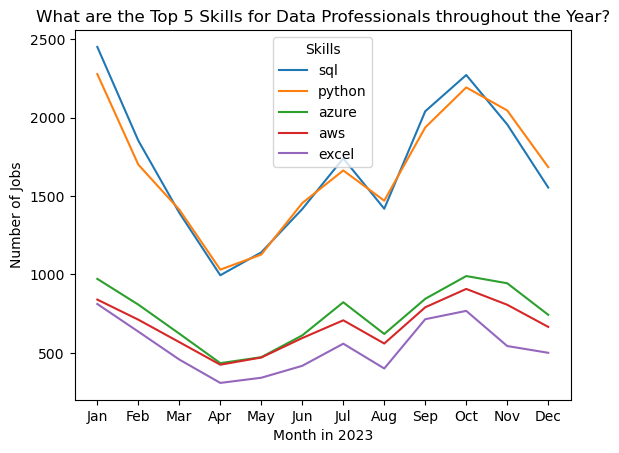

In [ ]:
# Plot top 5 skills on line grpah using Seaborn
# Top 5 skills (columns) are accessed with .iloc method
sns.lineplot(
    data=df_UK_exploded_pivot.iloc[:, :5],
    dashes=False,
)

plt.title("What are the Top 5 Skills for Data Professionals throughout the Year?")
plt.xlabel("Month in 2023")
plt.ylabel("Number of Jobs")
plt.legend(title="Skills"); # Add title to legend

# Plot skills on Line Graph based on Percentage

In [ ]:
# Return number of jobs posed each month
df_UK.groupby("job_posted_month_no").size()

job_posted_month_no
1     4781
2     3619
3     2773
4     2094
5     2236
6     2805
7     3187
8     2711
9     4191
10    4664
11    3969
12    3345
dtype: int64